🐍 PHASE 1: Python Exploratory Data Analysis (EDA)

1.1 Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# Load all datasets 
DATA_PATH = '/Users/tizianogallo/Desktop/Github/f1-analysis/data/'

races        = pd.read_csv(DATA_PATH + 'races.csv')
results      = pd.read_csv(DATA_PATH + 'results.csv')
drivers      = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors = pd.read_csv(DATA_PATH + 'constructors.csv')
lap_times    = pd.read_csv(DATA_PATH + 'lap_times.csv')
pit_stops    = pd.read_csv(DATA_PATH + 'pit_stops.csv')
qualifying   = pd.read_csv(DATA_PATH + 'qualifying.csv')
standings    = pd.read_csv(DATA_PATH + 'driver_standings.csv')
circuits     = pd.read_csv(DATA_PATH + 'circuits.csv')

# Quick sanity check
for name, df in zip(['races','results','drivers','constructors'], 
                    [races, results, drivers, constructors]):
    print(f"{name}: {df.shape} | NaN%: {df.isnull().mean().mean():.2%}")

races: (1125, 18) | NaN%: 0.00%
results: (26759, 18) | NaN%: 0.00%
drivers: (861, 9) | NaN%: 0.00%
constructors: (212, 5) | NaN%: 0.00%


1.2 Data Cleaning

In [8]:
# Replace '\\N' (Ergast null marker) with NaN
for df in [results, qualifying, lap_times, pit_stops]:
    df.replace('\\N', np.nan, inplace=True)

# Parse numeric columns
results['position']      = pd.to_numeric(results['positionOrder'], errors='coerce')
results['grid']          = pd.to_numeric(results['grid'], errors='coerce')
results['points']        = pd.to_numeric(results['points'], errors='coerce')
results['milliseconds']  = pd.to_numeric(results['milliseconds'], errors='coerce')
lap_times['milliseconds']= pd.to_numeric(lap_times['milliseconds'], errors='coerce')

# Parse qualifying times to milliseconds
def time_to_ms(t):
    try:
        m, s = str(t).split(':')
        return int(m) * 60000 + float(s) * 1000
    except:
        return np.nan

for col in ['q1', 'q2', 'q3']:
    qualifying[f'{col}_ms'] = qualifying[col].apply(time_to_ms)

# Add driver full name
drivers['full_name'] = drivers['forename'] + ' ' + drivers['surname']

# Merge year into results
results = results.merge(races[['raceId', 'year', 'circuitId']], on='raceId')

1.3 Key EDA — Driver Analysis

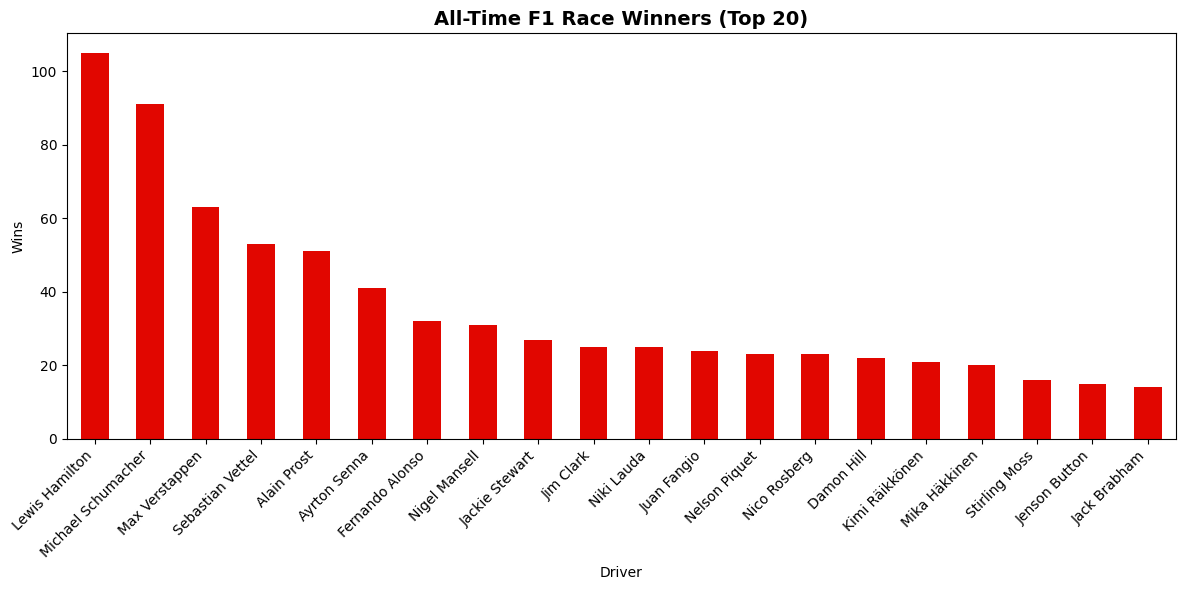

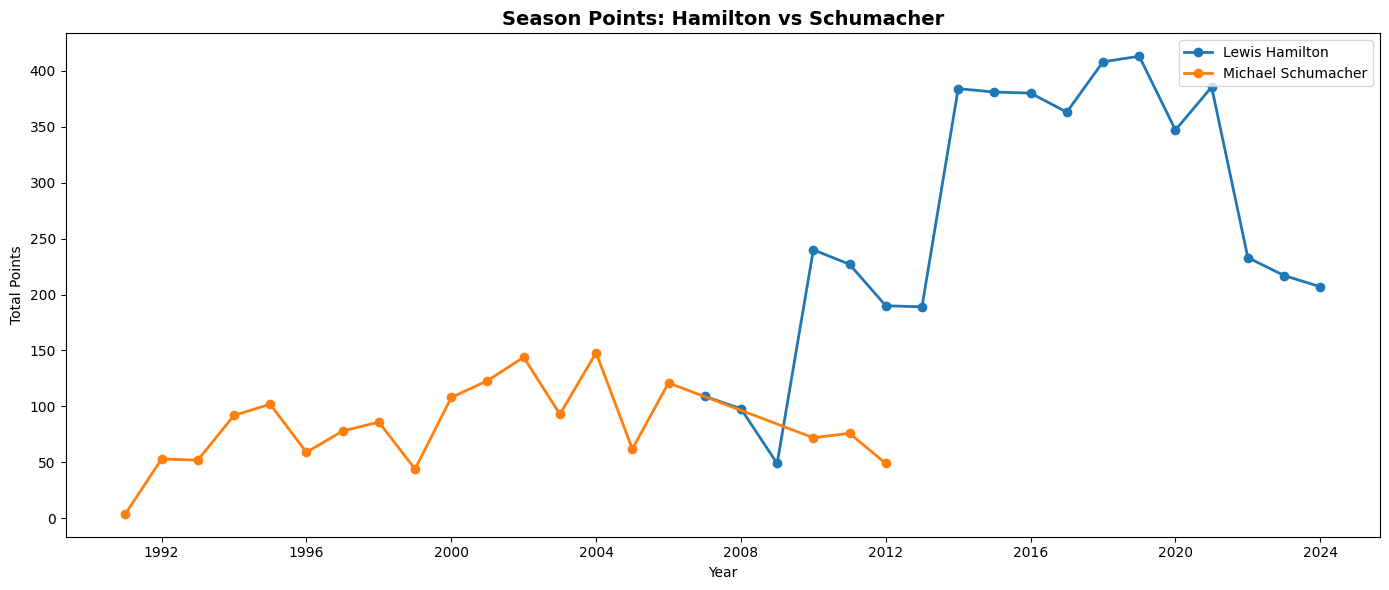

In [11]:
# --- Most race wins by driver (top 20) ---
wins = results[results['position'] == 1].merge(drivers[['driverId','full_name']], on='driverId')
top_winners = wins.groupby('full_name').size().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
top_winners.plot(kind='bar', color='#e10600')
plt.title('All-Time F1 Race Winners (Top 20)', fontsize=14, fontweight='bold')
plt.xlabel('Driver')
plt.ylabel('Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
EXPORT_PATH = '/Users/tizianogallo/Desktop/Github/f1-analysis/exports/'

plt.savefig(EXPORT_PATH + 'top_winners.png', dpi=150)
plt.show()

# --- Points per season evolution for Hamilton & Schumacher ---
legends = ['Lewis Hamilton', 'Michael Schumacher']
fig, ax = plt.subplots(figsize=(14, 6))
for driver in legends:
    did = drivers[drivers['full_name'] == driver]['driverId'].values[0]
    data = results[results['driverId'] == did].groupby('year')['points'].sum()
    ax.plot(data.index, data.values, marker='o', label=driver, linewidth=2)

ax.set_title('Season Points: Hamilton vs Schumacher', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Points')
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig(EXPORT_PATH + 'legends_comparison.png', dpi=150)
plt.show()

1.4 Key EDA — Constructor Analysis


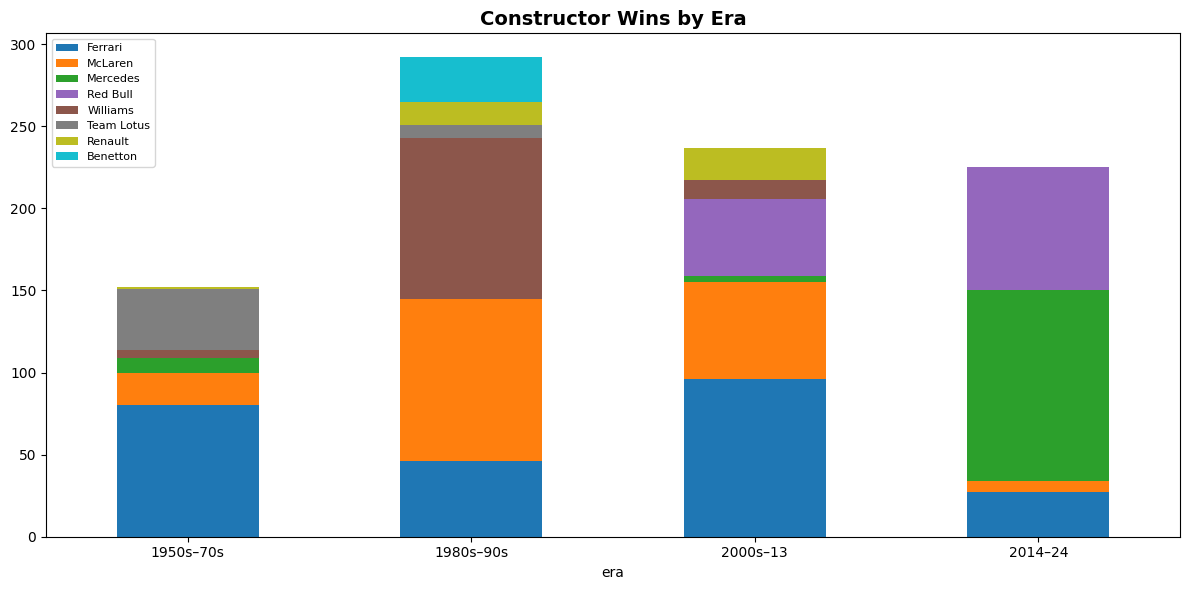

In [13]:
# Constructor wins per era
era_wins = results[results['position'] == 1].merge(
    constructors[['constructorId','name']], on='constructorId'
)

era_wins['era'] = pd.cut(era_wins['year'], 
    bins=[1949,1979,1999,2013,2024], 
    labels=['1950s–70s','1980s–90s','2000s–13','2014–24'])

era_pivot = era_wins.groupby(['era','name']).size().unstack(fill_value=0)
top8 = era_pivot.sum().nlargest(8).index
era_pivot[top8].plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab10')
plt.title('Constructor Wins by Era', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(EXPORT_PATH + 'constructor_eras.png', dpi=150)
plt.show()

1.5 Key EDA — Qualifying vs Race Performance

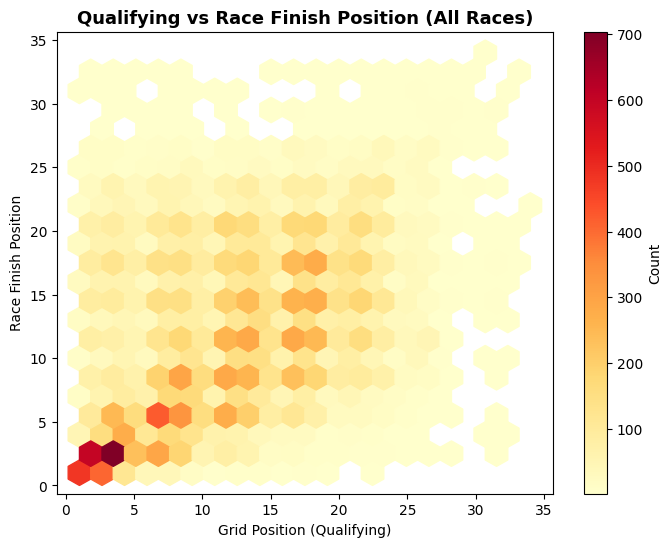

Correlation between grid & finish position: 0.446


In [14]:
# Grid position vs final position correlation
grid_race = results[['grid','position']].dropna()
grid_race = grid_race[(grid_race['grid'] > 0) & (grid_race['position'] > 0)]

plt.figure(figsize=(8, 6))
plt.hexbin(grid_race['grid'], grid_race['position'], gridsize=20, cmap='YlOrRd', mincnt=1)
plt.colorbar(label='Count')
plt.xlabel('Grid Position (Qualifying)')
plt.ylabel('Race Finish Position')
plt.title('Qualifying vs Race Finish Position (All Races)', fontsize=13, fontweight='bold')
plt.savefig(EXPORT_PATH + 'grid_vs_finish.png', dpi=150)
plt.show()

corr = grid_race.corr().iloc[0,1]
print(f"Correlation between grid & finish position: {corr:.3f}")